In [1]:
import numpy as np
import matplotlib.pyplot as plt

import preprocessing as prep
import visualization as vis
from filtering import LPF

In [3]:
DATA_DIR = "sphinx-hf-2"

SENSORS = {"b_load_1": "LC1 Axial Load",
           "pres_1": "PT1 Combustion Chamber Pressure",
           "pres_2": "PT2 Feedline Pressure",
           "pres_3": "PT3 Injector Pressure",
           "pres_4": "PT4 Ox-Tank Pressure"}

DRIVERS = {0: {"name": "Ox Fill", "False": "Close", "True": "Open"},
            1: {"name": "Ground Vent", "False": "Close", "True": "Open"},
            5: {"name": "Pressurization", "False": "Open", "True": "Close"},
            3: {"name": "remote purge", "False": "Close", "True": "Open"},
            4:{"name": "fuel run", "False": "Close", "True": "Open"},
            5: {"name": "nitrous purge", "False": "Close", "True": "Open"},
            6: {"name": "Ignition", "False": "Shutoff", "True": "Ignite"}}

In [4]:
print("Processing events")
prep.process_events_quonkboard(DATA_DIR, DRIVERS)
print("Processing data")
prep.process_data(DATA_DIR, SENSORS)
print("Done!")
# 33
# 6509

Processing events
 contents: 45853
45853
Processing data
Done!


In [5]:
events = prep.import_events(DATA_DIR)
#print(events[57])
#events = [{'secs': '9695', 'elapsed': '00:00', 'delta': '00:00', 'type': 'Ignition', 'info': ''}, {'secs': '10000', 'elapsed': '00:00', 'delta': '00:00', 'type': 'End', 'info': ''}]
labels, data = prep.import_data(DATA_DIR, events)
#print(labels)
times = data[:, 0]
i = 0
print(f"HF1 Data Summary \n----------------- \n Sensors: {len(labels) - 1} \n" f" Samples: {len(times)} \n Events:  {len(events)}")

HF1 Data Summary 
----------------- 
 Sensors: 5 
 Samples: 1804201 
 Events:  33


In [6]:
ep = vis.EventPlotter(data, events, dpi=100)
lpf = LPF(fs=300, length=101, cutoff=10, window="blackman")

In [ ]:
ep.plot(sensor_id=1, event_id=20, duration=70, filter=lpf,
        title="Load (HF3 Ignition)", ylabel="Load (lbf)",
        num_xticks=11, dif_yticks=10)


322200
622200
[-1.49023  0.00733  0.00733 ...  2.83606  2.66967  2.00409]


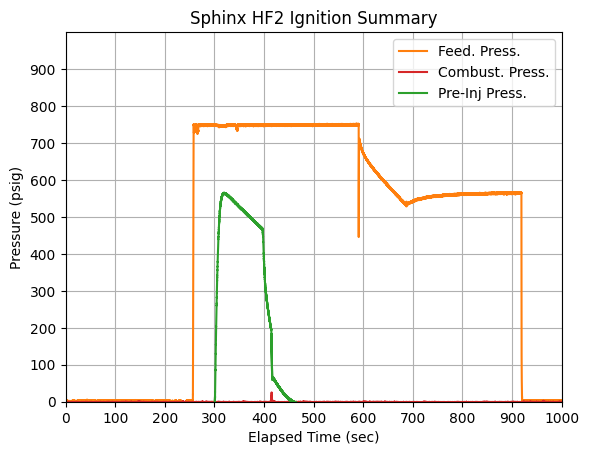

In [ ]:
ep.plot(sensor_id=3, event_id=19, duration=500, filter=None,
        title="Sphinx HF2 Ignition Summary", ylabel="Pressure (psig)",
        legend="Feed. Press.", num_xticks=11, dif_yticks=100,color="tab:orange")
ep.add_curve(sensor_id=2, event_id=19, duration=500, legend="Combust. Press.",
             color="tab:red")
ep.add_curve(sensor_id=4, event_id=19, duration=500, legend="Pre-Inj Press.",
             color="tab:green")
plt.ylim(0,1000)
plt.yticks(range(0, 901, 100)) 

plt.grid(True)
plt.show()

In [ ]:
ep.plot(sensor_id=1, event_id=20, duration=40, filter=None,
        title="Proxima HF2C Ignition Summary", ylabel="Load (lbf)",
        legend="Axial Load", num_xticks=11, dif_yticks=10, color="tab:orange",)
ep.add_curve(sensor_id=2, event_id=20, duration=40, legend="Combust. Press.",
             color="tab:red")
ep.add_curve(sensor_id=4, event_id=20, duration=40, legend="Pre-Injection Press.", 
             color="tab:blue")
plt.show()